In [1]:
import argparse
import os
import sys
import pickle as pkl
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
from concurrent.futures import ProcessPoolExecutor, as_completed
import time
import traceback

warnings.filterwarnings("ignore")

from one.api import ONE
from brainbox.io.one import SessionLoader
from brainwidemap import load_trials_and_mask

from communication_subspace.ibl_communication.utils import load_widefield_epoch, setup_logger
from communication_subspace.ibl_communication.crossvalidated_rrr import optimize_rrr_rank
from iblatlas.atlas import AllenAtlas
from iblatlas.regions import BrainRegions
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import pickle as pkl
from glob import glob
import seaborn as sns
from manifold.widefield_ppi import return_labels



In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from manifold.crosstemporal_plotting import combine_data_frames, prepare_and_aggregate, prepare_extremes_only, plot_decoder_extremes, plot_decoder_evolution

In [4]:
trainedoncongruentonly = glob('../data/generated/temporal_crosstemporal_new/*_temporal_congruent_rawregions_projections.pqt')

In [5]:
combined_df = combine_data_frames(trainedoncongruentonly)

In [7]:
extreme_differences_stim, extereme_differences_choice = prepare_extremes_only(combined_df)
differences_stim, differences_choice = prepare_and_aggregate(combined_df)

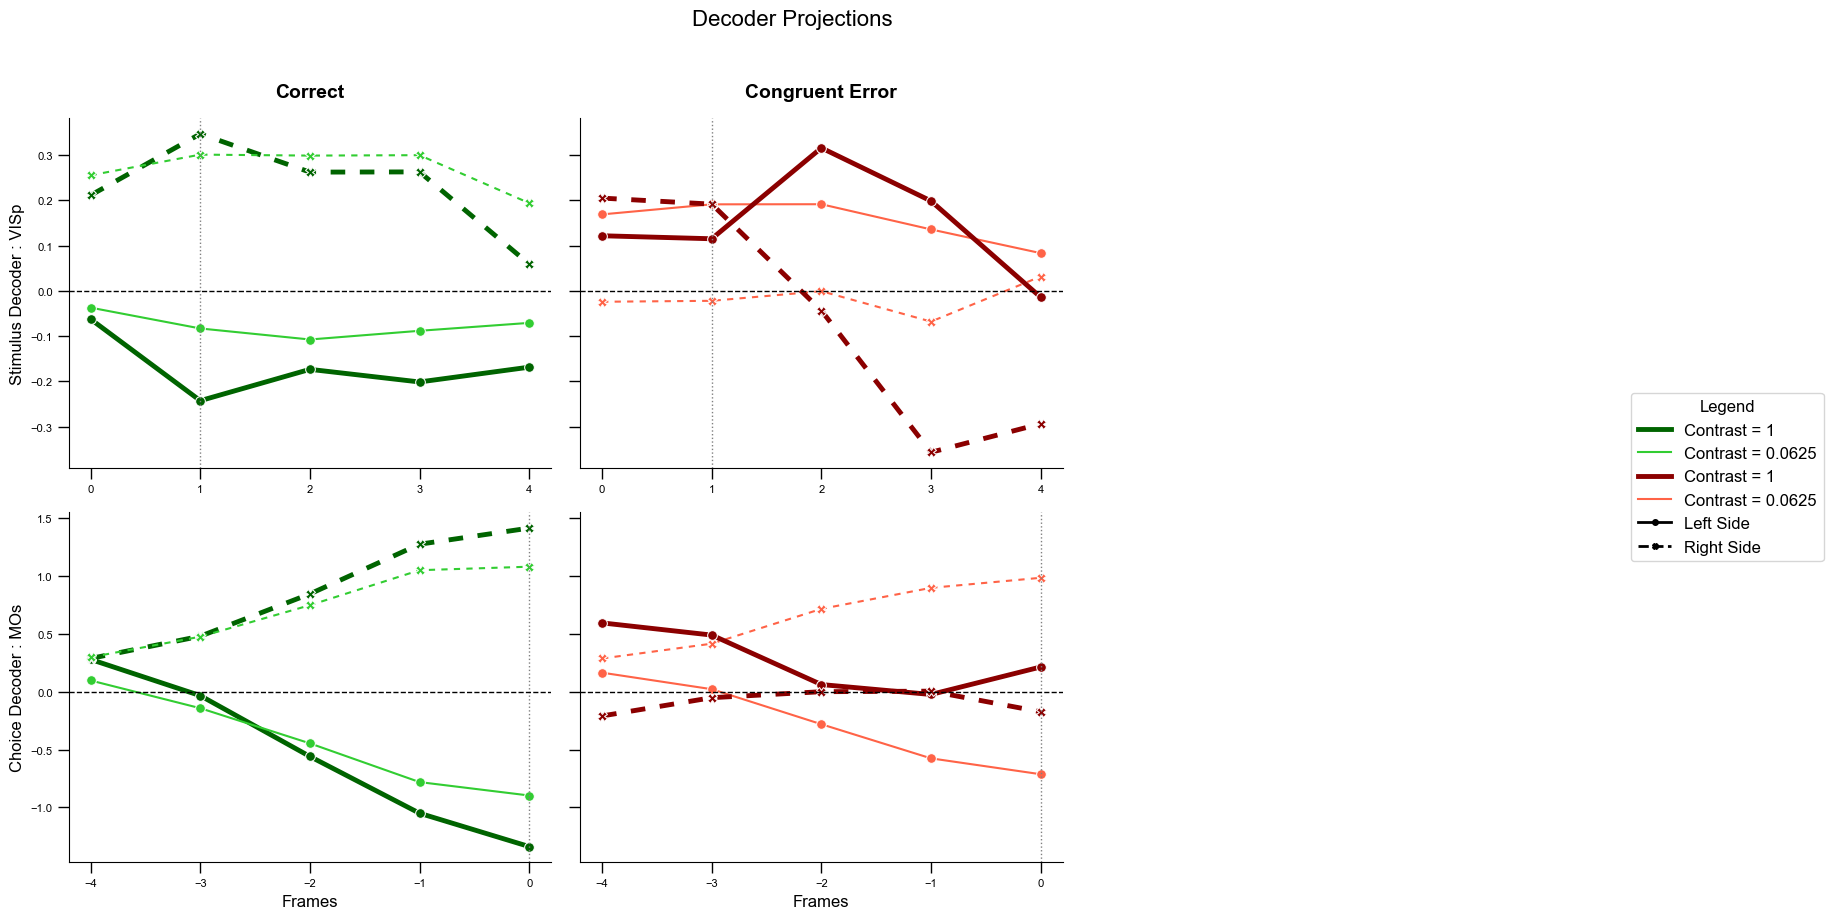

In [9]:
plot_decoder_extremes(extreme_differences_stim, extereme_differences_choice)

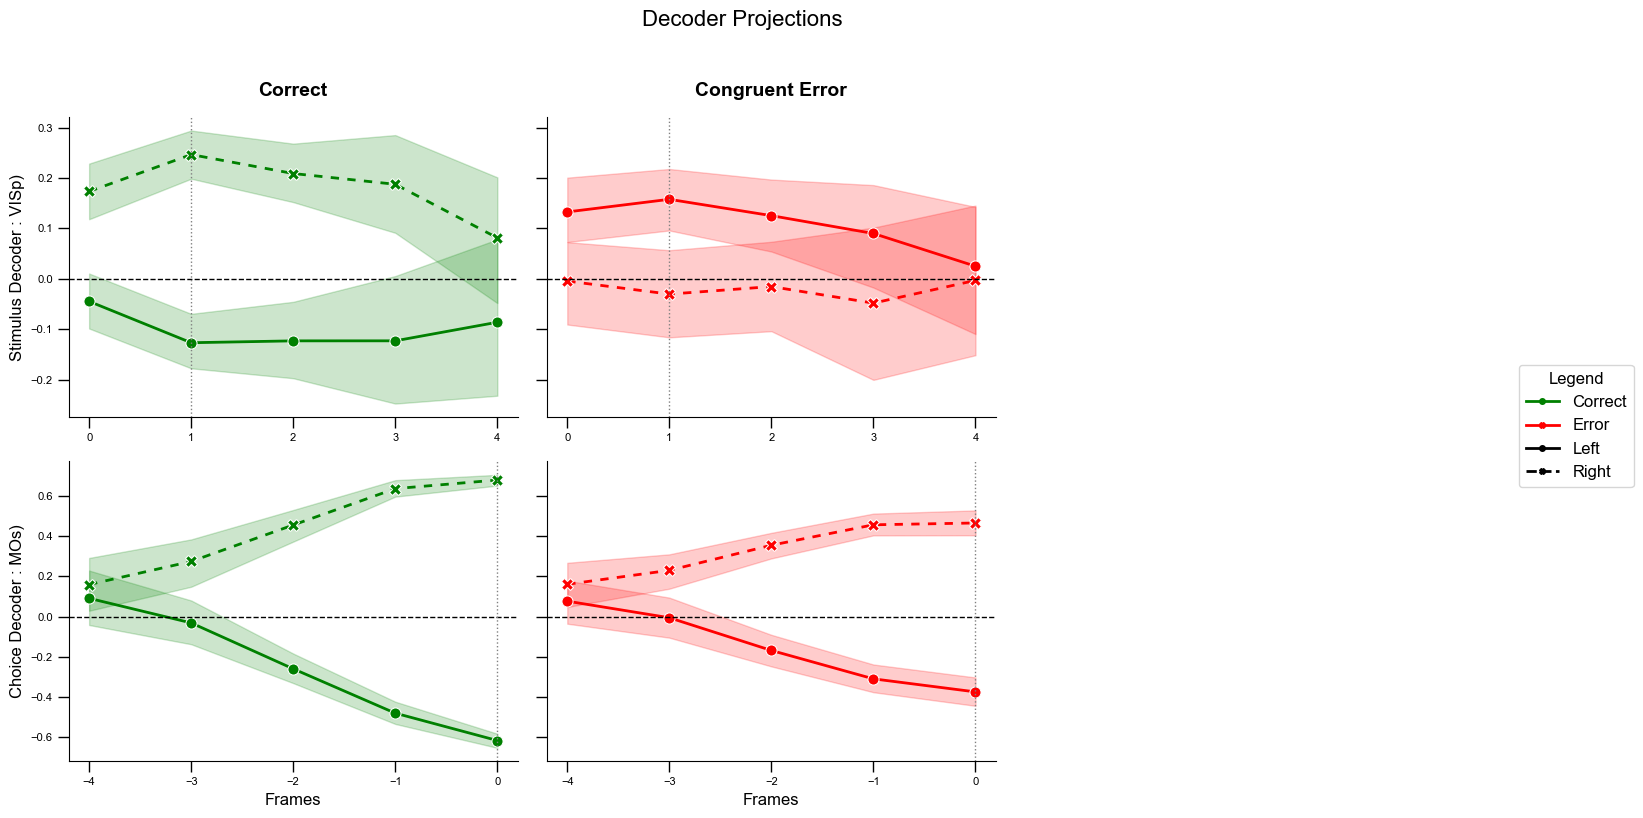

In [17]:
plot_decoder_evolution(differences_stim, differences_choice)

### All trials

In [14]:
trainedonall = glob('../data/generated/temporal_crosstemporal_new/*_temporal_projections.pqt')
combined_df_all = combine_data_frames(trainedonall)
extreme_differences_stim_all, extereme_differences_choice_all = prepare_extremes_only(combined_df_all)
differences_stim_all, differences_choice_all = prepare_and_aggregate(combined_df_all)

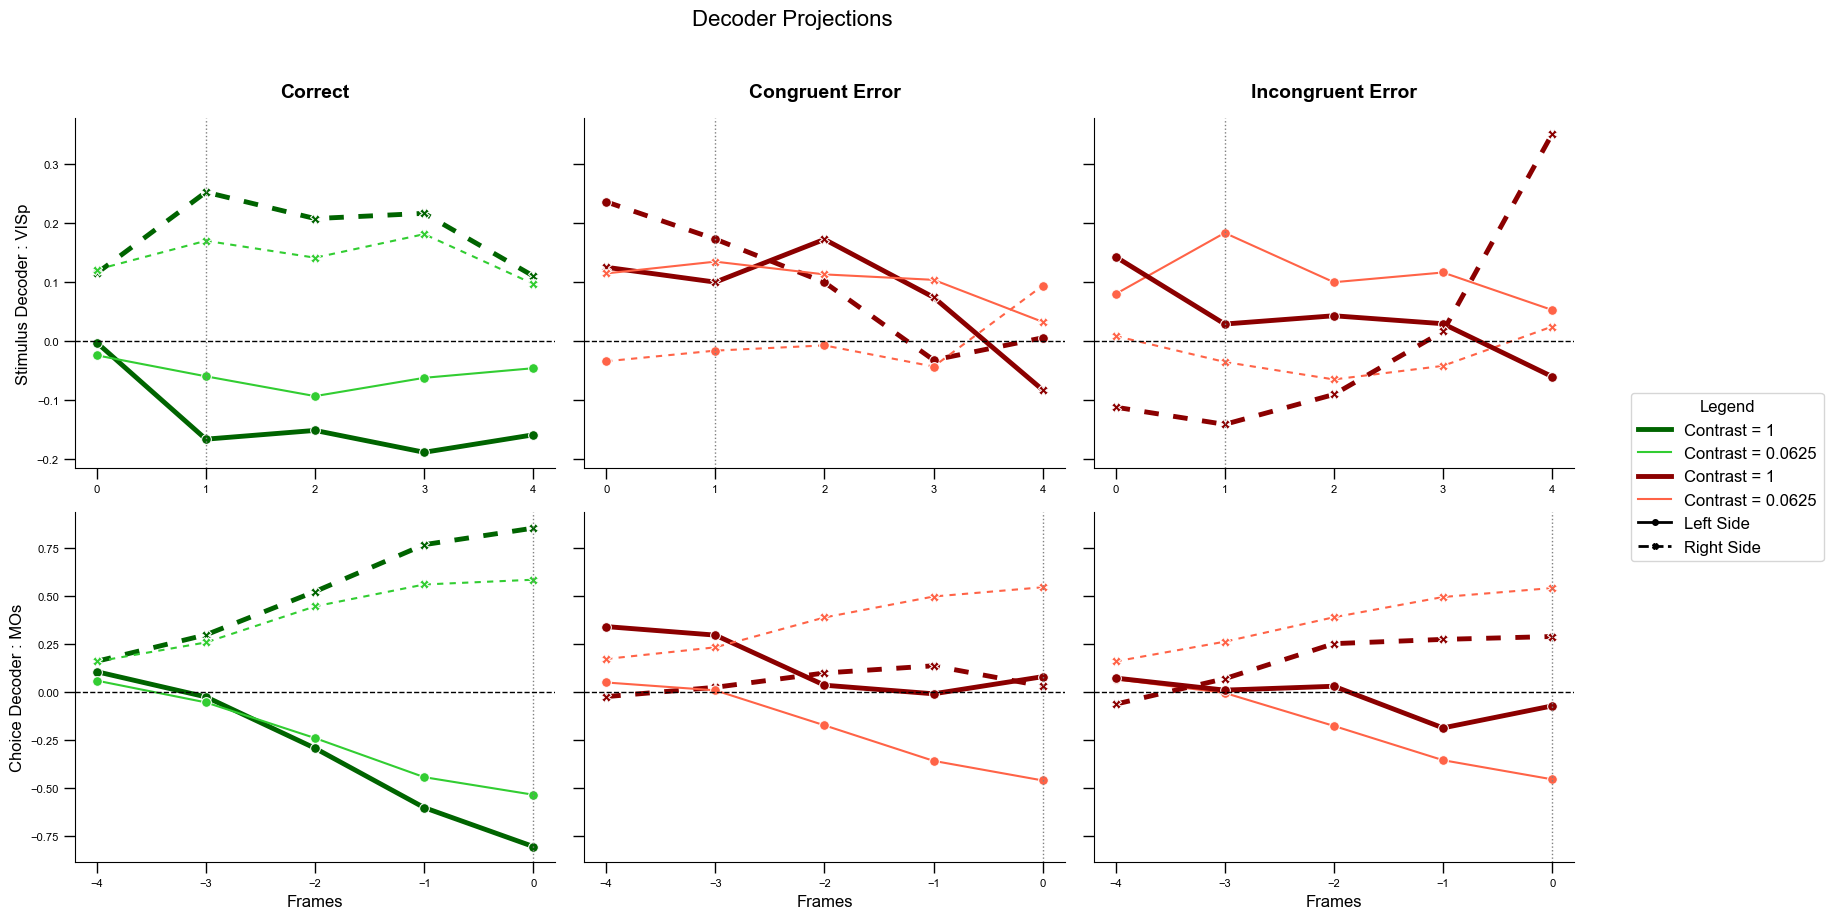

In [15]:
plot_decoder_extremes(extreme_differences_stim_all, extereme_differences_choice_all)

In [33]:
A = len(combined_df[(combined_df['is_congruent']) & (combined_df['is_correct_trial']==False) & (np.abs(combined_df['signed_contrast'])==1)])/len(combined_df[(combined_df['is_congruent']) & (np.abs(combined_df['signed_contrast'])==1)])

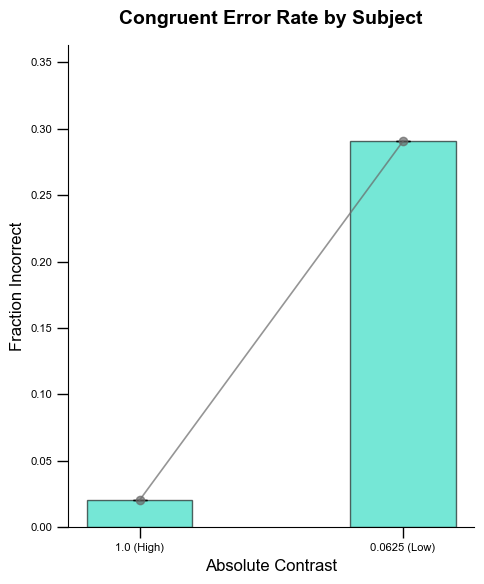

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = combined_df.copy()

subject_col = 'subject_uuid' if 'subject_uuid' in df.columns else 'mouse_name'
if subject_col not in df.columns:
    df['subject_uuid'] = 'single_subject'
    subject_col = 'subject_uuid'

# 1. Filter for congruent trials at extreme contrasts
df_cong = df[
    df['is_congruent'] & 
    df['signed_contrast'].abs().isin([1.0, 0.0625])
].copy()

df_cong['abs_contrast'] = df_cong['signed_contrast'].abs()
df_cong['is_error'] = df_cong['is_correct_trial'] == False

# 2. Compute error rate per subject and contrast
subject_error_rates = df_cong.groupby([subject_col, 'abs_contrast'])['is_error'].mean().reset_index(name='fraction_incorrect')

# 3. Compute mean and SEM safely (handling cases with few subjects)
summary_stats = subject_error_rates.groupby('abs_contrast')['fraction_incorrect'].agg(
    mean='mean',
    sem=lambda x: x.sem(ddof=1) if len(x) > 1 else 0.0
).reset_index()

# Sort to ensure high contrast (1.0) is first, low contrast (0.0625) is second
summary_stats = summary_stats.sort_values('abs_contrast', ascending=False).reset_index(drop=True)

# 4. Plotting
fig, ax = plt.subplots(figsize=(5, 6))
x_pos = np.arange(len(summary_stats))

# Draw bars
ax.bar(
    x_pos, 
    summary_stats['mean'], 
    color='#1ad7bb', 
    edgecolor='k', 
    alpha=0.6, 
    width=0.4
)

# Draw explicit error bars on top of the bars
ax.errorbar(
    x_pos, 
    summary_stats['mean'], 
    yerr=summary_stats['sem'], 
    fmt='none', 
    ecolor='black', 
    elinewidth=1.5, 
    capsize=5
)

# Pivot to wide format to overlay individual subject lines
pivot_df = subject_error_rates.pivot(index=subject_col, columns='abs_contrast', values='fraction_incorrect').dropna()

if 1.0 in pivot_df.columns and 0.0625 in pivot_df.columns:
    for subject, row in pivot_df.iterrows():
        ax.plot(
            [0, 1], 
            [row[1.0], row[0.0625]], 
            marker='o', 
            markersize=6,
            color='dimgray', 
            alpha=0.7, 
            linestyle='-', 
            linewidth=1.2
        )

# Formatting
ax.set_xticks(x_pos)
ax.set_xticklabels(['1.0 (High)', '0.0625 (Low)'])
ax.set_xlabel('Absolute Contrast', fontsize=12)
ax.set_ylabel('Fraction Incorrect', fontsize=12)
ax.set_title('Congruent Error Rate by Subject', fontsize=14, pad=15)

# Dynamic y-limit to ensure error bars fit nicely
max_val = (summary_stats['mean'] + summary_stats['sem']).max()
ax.set_ylim(0, max_val * 1.25 if not np.isnan(max_val) else 0.5)

sns.despine()
plt.tight_layout()
plt.show()